# Retail Sales Analysis
## Exploratory Data Analysis (EDA) Project

## Phase 1: Data Loading & Inspection

## Problem Statement

The objective of this analysis is to identify the key factors driving retail revenue by analyzing customer behavior, product categories, and time-based trends. The goal is to derive actionable insights that help the business optimize pricing strategies, improve customer targeting, and enhance overall sales performance.


## Business Questions

This exploratory data analysis aims to answer the following key questions:

1. Which product categories generate the highest revenue?
2. What is the distribution of customer demographics (age, gender)?
3. Which customer segments contribute the most to sales?
4. How do purchasing patterns vary across different months?
5. Is there any relationship between quantity purchased, price, and revenue?
6. Are there any unusual patterns or anomalies in the dataset?
7. Which products or categories should the business focus on to maximize revenue?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style = 'whitegrid')

In [2]:
df = pd.read_csv('retail_sales_dataset.csv')
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


In [3]:
df.shape

(1000, 9)

In [4]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [6]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


## Initial Observations

- The dataset contains **1000 rows and 9 columns**
- All columns have **1000 non-null values**, indicating **no missing data**
- Data types:
  - Numerical columns: Age, Quantity, Price per Unit, Total Amount
  - Categorical columns: Gender, Product Category, Customer ID
  - Date column is currently stored as **object type**, needs conversion

- The dataset appears clean in terms of missing values, but further checks are required for:
  - Duplicate records
  - Outliers in numerical columns
  - Correct data types (especially Date)

Initial Conclusion:
The dataset is structurally complete with no missing values, but preprocessing steps like date conversion and validation checks are still necessary before analysis.

## Phase 2: Data Cleaning

In [7]:
# missing values
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [8]:
# duplicates
df.duplicated().sum()

np.int64(0)

In [9]:
df['Date'] = pd.to_datetime(df['Date'])

In [10]:
df['Gender'] =df['Gender'].astype('category')
df['Product Category'] = df['Product Category'].astype('category')

In [11]:
df['Calculated Total'] = df['Quantity'] * df['Price per Unit']
(df['Calculated Total'] == df['Total Amount']).all()

np.True_

In [12]:
df.drop(columns = ['Calculated Total'],inplace=True)

In [13]:
df.rename(columns={'Total Amount':'Revenue'},inplace=True)

## Data Cleaning & Preparation Summary

- No missing values or duplicate records were found, indicating good data quality
- Date column was converted to datetime format for proper time-based analysis
- Converted categorical columns (Gender, Product Category) to category dtype for improved efficiency and clearer segmentation
- Data validation confirmed that Total Amount is correctly calculated from Quantity and Price per Unit
- Removed the temporary column after validation
- Renamed 'Total Amount' to 'Revenue' for better business interpretation

Conclusion:
The dataset is clean, consistent, and ready for further analysis

## Phase 3: Feature Engineering

In [14]:
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['Day'] = df['Date'].dt.day
print(df)

     Transaction ID       Date Customer ID  Gender  Age Product Category  \
0                 1 2023-11-24     CUST001    Male   34           Beauty   
1                 2 2023-02-27     CUST002  Female   26         Clothing   
2                 3 2023-01-13     CUST003    Male   50      Electronics   
3                 4 2023-05-21     CUST004    Male   37         Clothing   
4                 5 2023-05-06     CUST005    Male   30           Beauty   
..              ...        ...         ...     ...  ...              ...   
995             996 2023-05-16     CUST996    Male   62         Clothing   
996             997 2023-11-17     CUST997    Male   52           Beauty   
997             998 2023-10-29     CUST998  Female   23           Beauty   
998             999 2023-12-05     CUST999  Female   36      Electronics   
999            1000 2023-04-12    CUST1000    Male   47      Electronics   

     Quantity  Price per Unit  Revenue  Month  Year  Day  
0           3              5

In [15]:
df['Age Group'] = pd.cut(df['Age'],bins=[0,25,45,65,100],
                        labels=['Young','Adult','Mid-Age','Senior'])
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Revenue,Month,Year,Day,Age Group
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,11,2023,24,Adult
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2,2023,27,Adult
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,1,2023,13,Mid-Age
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,5,2023,21,Adult
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,5,2023,6,Adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50,5,2023,16,Mid-Age
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90,11,2023,17,Mid-Age
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100,10,2023,29,Young
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150,12,2023,5,Adult


## Feature Engineering

- Extracted Month, Year, and Day from the Date column to enable time-based analysis
- Created Age Group segmentation for better understanding of customer demographics

Insight:
These features allow deeper analysis of customer behavior and seasonal sales patterns, supporting better business decision-making

## Phase 4: Outlier Detection & Treatment

<Axes: xlabel='Revenue'>

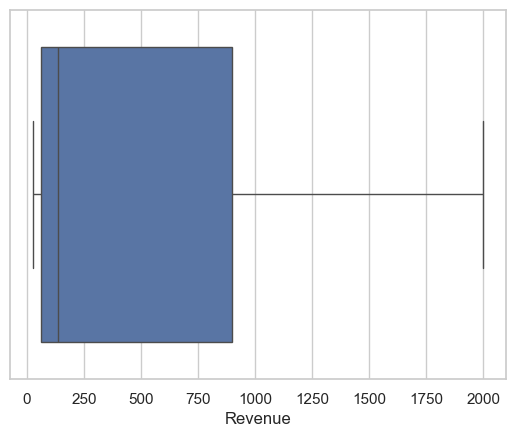

In [16]:
sns.boxplot(x=df['Revenue'])

In [17]:
Q1 = df['Revenue'].quantile(0.25)
Q3 = df['Revenue'].quantile(0.75)
IQR = Q3 - Q1
print("Q1=",Q1)
print("Q3=",Q3)
print("IQR=",IQR)

Q1= 60.0
Q3= 900.0
IQR= 840.0


In [18]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Upper Bound:",upper_bound)
print("Lower Bound:",lower_bound)

Upper Bound: 2160.0
Lower Bound: -1200.0


In [19]:
outliers = df[(df['Revenue'] < lower_bound) | (df['Revenue'] > upper_bound)]

len(outliers)

0

## Outlier Analysis

- The IQR method (1.5 × IQR) was used to detect outliers in the Revenue column
- The calculated lower and upper bounds were approximately -1200 and 2160
- No data points were found outside this range

Insight:
This indicates that the dataset does not contain significant outliers and the revenue values are reasonably distributed. Therefore, no outlier treatment was required.

## Phase 5: Exploratory Data Analysis (EDA)

After ensuring the dataset is clean, consistent, and free from significant outliers, the next step is to explore the data to uncover patterns, trends, and relationships.

This phase includes:
- Univariate Analysis (analyzing individual variables)
- Bivariate Analysis (analyzing relationships between variables)
- Time-based Analysis (identifying trends over time)

### 5.1 Univariate Analysis

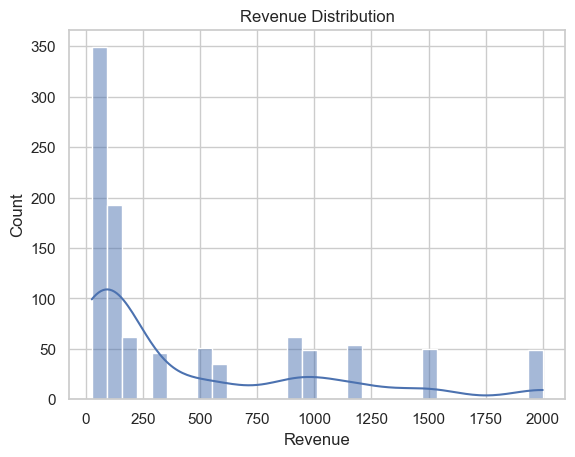

In [20]:
## 1.Revenue Distribution
sns.histplot(df['Revenue'],bins = 30 ,kde=True)
plt.title("Revenue Distribution")
plt.show()

- The distribution of revenue appears to be right-skewed 
- Most transactions fall within a lower revenue range
- A few higher-value transactions are present

Insight:
Retail sales are primarily driven by smaller transactions, with occasional high-value purchases contributing to overall revenue

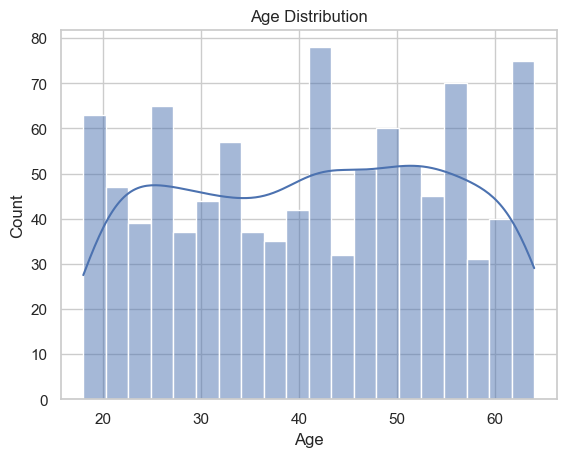

In [21]:
## 2.Age Distribution
sns.histplot(df['Age'],bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

- Age distribution is fairly spread across 18–65
- Slight concentration observed in the 35–55 range
- No extreme skewness in age distribution

Insight:
Customer base is diverse in age, with middle-aged customers forming a key segment contributing consistently to sales

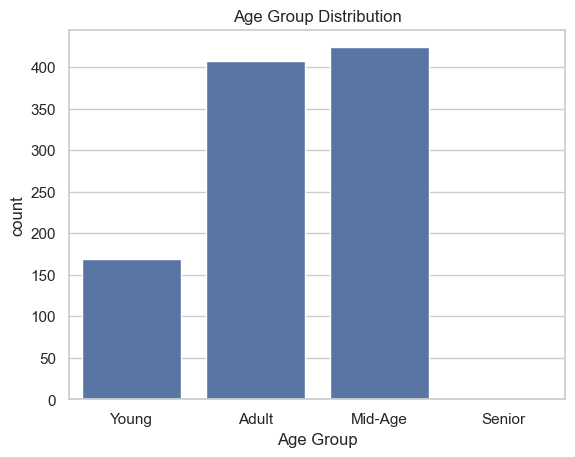

In [22]:
## 3.Age Group Distribution
sns.countplot(x='Age Group',data=df)
plt.title("Age Group Distribution")
plt.show()

- Adult and Mid-Age groups have the highest counts
- Young segment has comparatively fewer customers
- Senior segment contribution is minimal

Insight:
Retail sales are primarily driven by Adult and Mid-Age customers, indicating strong purchasing power from working-class segments

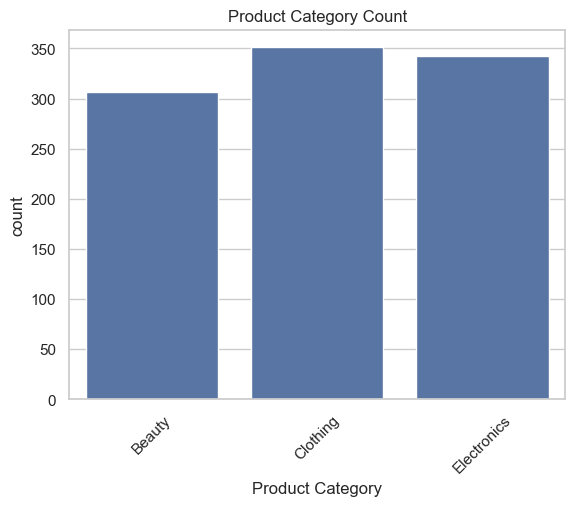

In [23]:
## 4.Product Category Count
sns.countplot(x="Product Category",data=df)
plt.title("Product Category Count")
plt.xticks(rotation=45)
plt.show()

- Clothing has the highest transaction count
- Electronics and Beauty follow closely
- No category shows extremely low demand

Insight:
Sales are well distributed across categories, with Clothing acting as a major driver while other categories provide balanced support

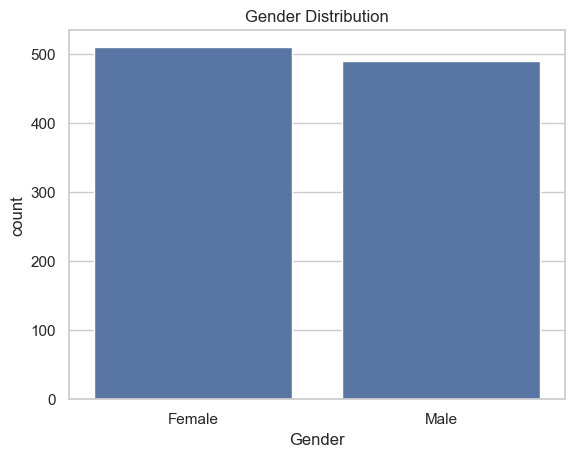

In [24]:
## 5.Gender Distribution
sns.countplot(x="Gender",data=df)
plt.title("Gender Distribution")
plt.show()

- Female customers slightly outnumber male customers
- Overall distribution is nearly balanced
-No significant gender gap observed

Insight:
Customer base is gender-balanced, with a slight inclination toward female customers contributing marginally more to transactions

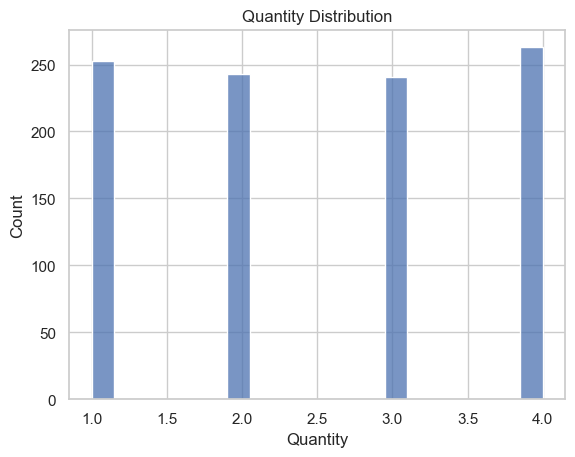

In [25]:
## 6.Quantity Distribution
sns.histplot(df['Quantity'],bins = 20)
plt.title("Quantity Distribution")
plt.show()

- Quantity values are concentrated between 1 to 4 units
- Most transactions involve low purchase quantities
- No extreme high-quantity purchases observed

Insight:
Retail transactions are primarily low-volume purchases, indicating customers tend to buy in smaller quantities per transaction

### 5.2 Bivariate Analysis

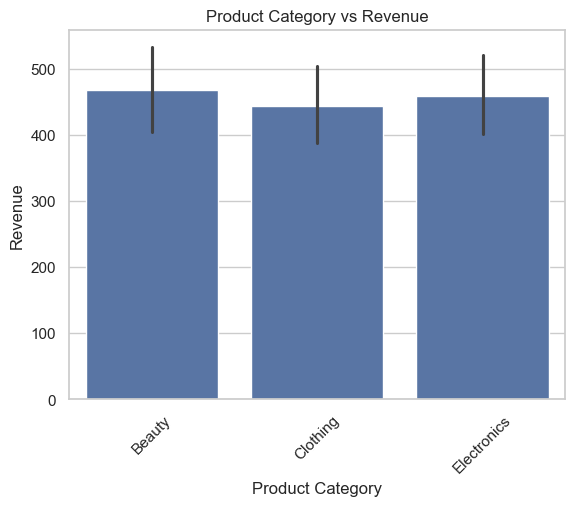

In [26]:
## 1.Product Category vs Revenue
sns.barplot(x='Product Category',y='Revenue',data=df)
plt.title("Product Category vs Revenue")
plt.xticks(rotation=45)
plt.show()

- Revenue contribution is fairly similar across all categories
- Beauty shows slightly higher average revenue
- Clothing has slightly lower average compared to others

Insight:
Revenue is evenly distributed across product categories, with no single category dominating, indicating a balanced revenue stream

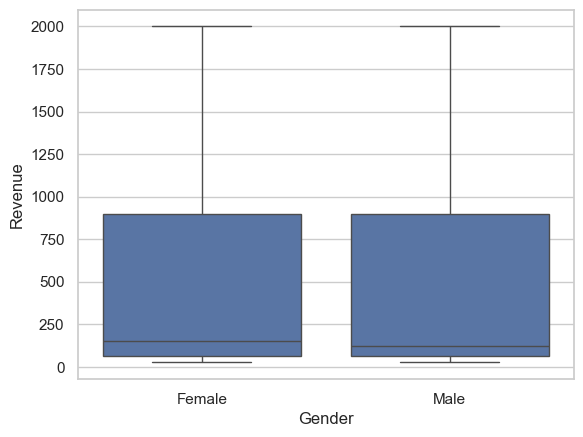

In [27]:
## 2.Gender vs Revenue
sns.boxplot(x='Gender',y='Revenue',data=df)
plt.show()

- Female customers contribute slightly higher revenue
- Male contribution is nearly comparable
- No major gap observed between genders

Insight:
Revenue contribution is balanced across genders, with a slight dominance from female customers

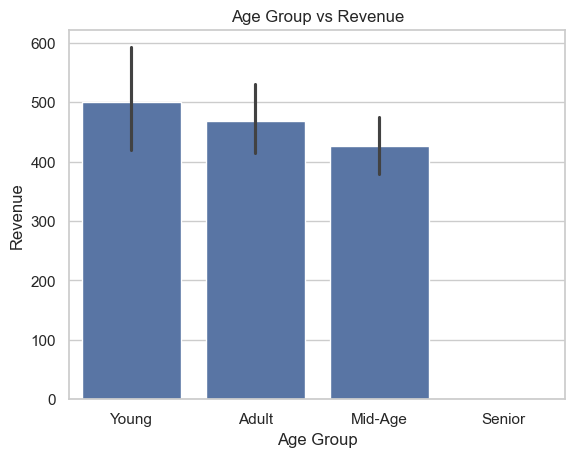

In [28]:
## 3.Age Group vs Revenue
sns.barplot(x='Age Group',y='Revenue',data=df)
plt.title("Age Group vs Revenue")
plt.show()

- Young customers show the highest average revenue
- Adult group contributes consistently
- Mid-Age group shows relatively lower average revenue

Insight:
Younger customers contribute higher average spending per transaction, while Adult customers provide stable revenue contribution

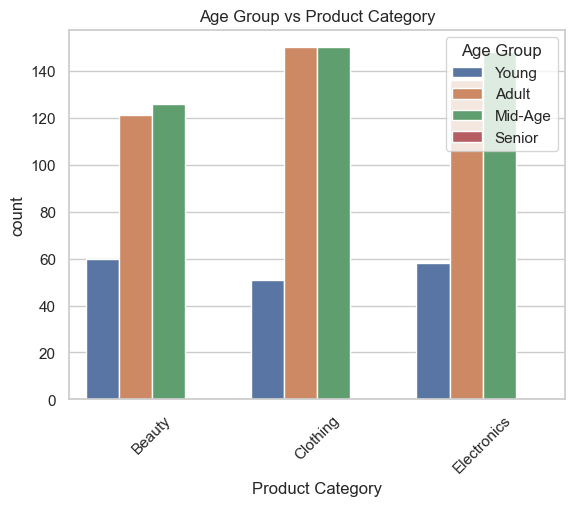

In [29]:
## 4.Age Group vs Product Category
sns.countplot(x = 'Product Category', hue='Age Group', data=df)
plt.xticks(rotation=45)
plt.title("Age Group vs Product Category")
plt.show()

- Adult and Mid-Age customers dominate across all categories
- Young customers have lower participation in each category
- No category is exclusively dominated by a single age group

Insight:
Product demand is driven mainly by Adult and Mid-Age customers across all categories, indicating broad but consistent purchasing behavior

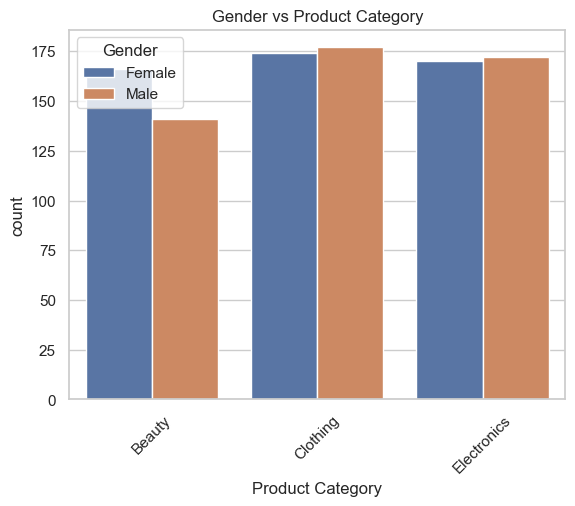

In [30]:
## 5.Gender vs Product Category
sns.countplot(x='Product Category',hue='Gender',data= df)
plt.xticks(rotation=45)
plt.title("Gender vs Product Category")
plt.show()

- Both genders contribute across all product categories
- Female customers show slightly higher participation in Beauty Products
- No major gender gap in category preference

Insight:
Product categories appeal to both genders, with slight variation in preference, allowing for balanced and inclusive marketing strategies

### 5.3 Multivariate Analysis

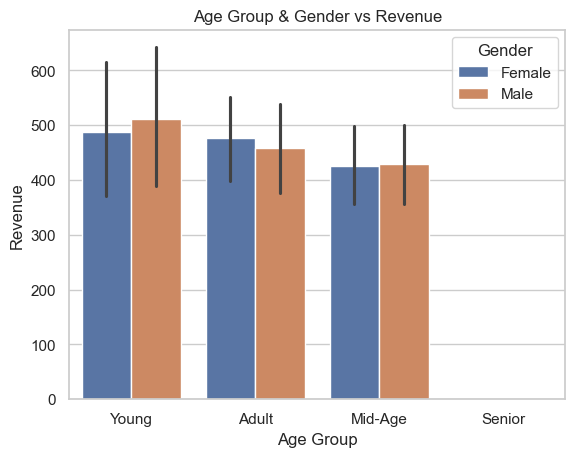

In [31]:
## 1.Age group+Gender vs Revenue
sns.barplot(x="Age Group",y="Revenue",hue="Gender",data=df)
plt.title("Age Group & Gender vs Revenue")
plt.show()

- Revenue declines consistently across age groups for both Male and Female customers
- Young customers generate the highest average revenue ( ≈ 490 Female,  ≈ 510 Male)
- Adult segment shows slightly higher spending from Female customers
- Mid-Age group shows near-identical revenue for both genders ( ≈ 425–430)
- Senior segment has negligible representation

Insight:
Revenue is primarily driven by younger customers across both genders, indicating age has a stronger influence on spending behavior than gender, with minimal gender differences observed in older segments

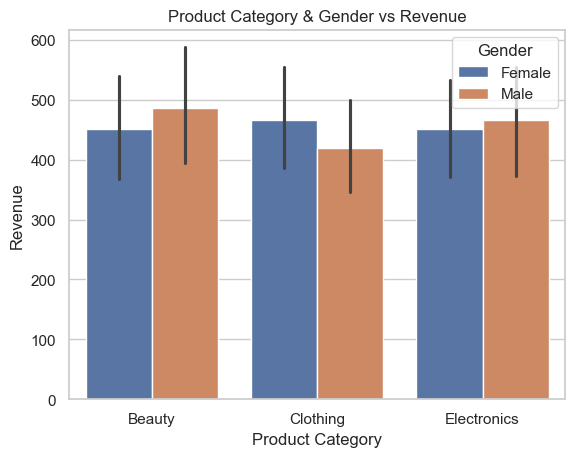

In [32]:
## 2.Product Category+Gender vs Revenue
sns.barplot(x="Product Category", y="Revenue",hue ="Gender",data=df)
plt.title("Product Category & Gender vs Revenue")
plt.show()

- Both genders contribute across all product categories
- Male customers generate slightly higher revenue in Beauty
- Female customers lead in Clothing with a noticeable gap
- Electronics shows near-equal revenue contribution from both genders

Insight:
Revenue is fairly balanced across genders for all categories, with minor variations, indicating no strong gender-specific preference, while targeted promotions can help optimize category-wise performance

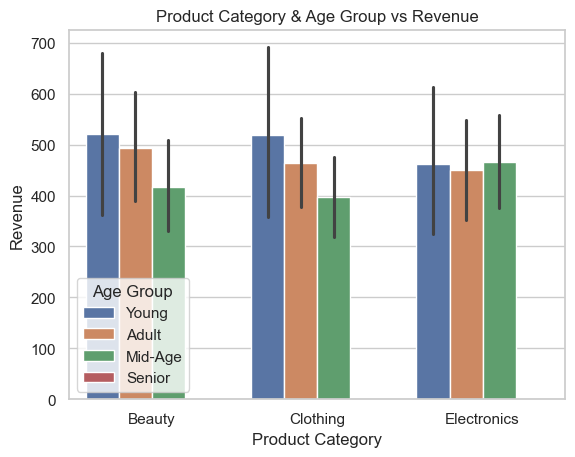

In [33]:
## 3.Product Category + Age Group vs Revenue
sns.barplot(x="Product Category",y="Revenue",hue="Age Group",data=df)
plt.title("Product Category & Age Group vs Revenue")
plt.show()

- Young customers generate the highest revenue in Beauty and Clothing
- Adult customers consistently contribute second-highest across all categories
- Mid-Age customers show lower revenue in Beauty and Clothing but higher in Electronics
- Electronics shows more balanced revenue across age groups
- Senior segment has negligible representation

Insight:
Young and Adult customers are the primary revenue drivers, while Mid-Age customers show category-specific preference toward Electronics, indicating opportunities for targeted product positioning by age group

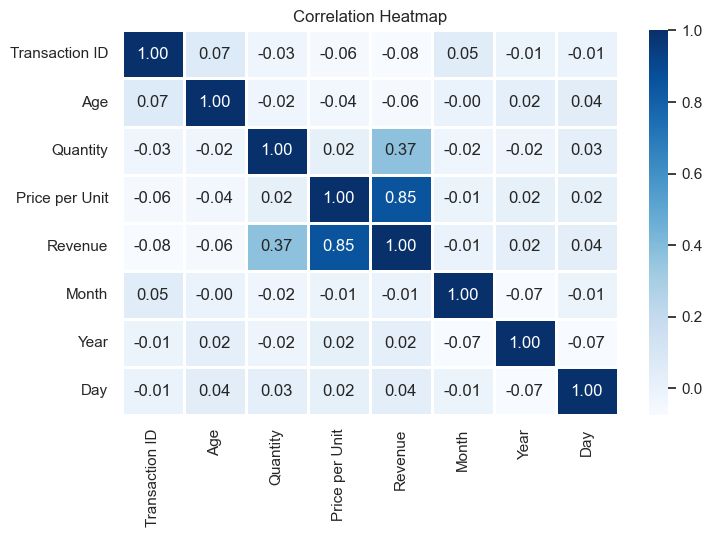

In [34]:
## Correlation Analysis
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True),annot= True,cmap='Blues',fmt=".2f",linewidth=2)
plt.title("Correlation Heatmap")
plt.show()

- Price per Unit and Revenue show a strong positive correlation ( ≈ 0.85)
- Quantity and Revenue show a moderate positive correlation ( ≈ 0.37)
- Quantity and Price per Unit have negligible correlation ( ≈ 0.02)
- Age shows near-zero correlation with all variables
- Time variables (Month, Day, Year) show negligible correlation with Revenue

Insight:
Revenue is primarily driven by Price per Unit, with Quantity contributing moderately, while demographic and time-based factors have minimal influence on sales

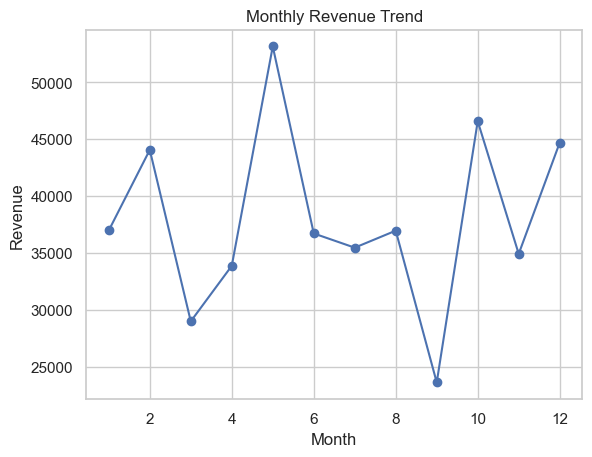

In [35]:
## Time Trend Analysis
monthly_revenue = df.groupby('Month')['Revenue'].sum()
monthly_revenue.plot(marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

- Revenue shows a fluctuating pattern across months with no consistent trend
- May records the highest revenue peak
- September shows the lowest revenue level
- Mid-year months (June–August) show relatively lower and stable revenue
- Revenue recovers in October and December after dips

Insight:
Revenue exhibits irregular fluctuations rather than clear seasonality, with peak and low-performing months indicating opportunities for targeted promotions and improved sales strategies during weaker periods

## Phase 6: Key EDA Insights & Observations

- Retail sales are primarily driven by younger and adult customers, with younger segments showing higher average spending
- Gender distribution is balanced, with only minor differences in revenue contribution across categories
- Clothing, Electronics, and Beauty all contribute significantly, indicating a well-diversified product portfolio
- Revenue is strongly influenced by Price per Unit, while Quantity plays a secondary role
- Customer demographics like Age and Gender have minimal direct impact on revenue generation
- Electronics shows more consistent performance across different customer segments compared to other categories
- Monthly revenue shows high fluctuations with no clear seasonality, indicating external factors influence sales
- Mid-year period (June–August) and September show weaker performance, while May and October are peak months

## Overall Observation
The business operates on a balanced customer base and diversified product categories, with revenue primarily driven by pricing strategy and influenced by time-based fluctuations rather than strong demographic factors

## Phase 7:Customer Segmentation

In [36]:
df['Spend_Level'] = pd.qcut(df['Revenue'],q=3,labels=['Low','Medium','High'])
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Revenue,Month,Year,Day,Age Group,Spend_Level
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,11,2023,24,Adult,Medium
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2,2023,27,Adult,High
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,1,2023,13,Mid-Age,Low
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,5,2023,21,Adult,Medium
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,5,2023,6,Adult,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50,5,2023,16,Mid-Age,Low
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90,11,2023,17,Mid-Age,Low
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100,10,2023,29,Young,Medium
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150,12,2023,5,Adult,Medium


In [37]:
df['Age Group'] = df['Age Group'].cat.remove_unused_categories()

In [38]:
## segmentation table
seg_table = df.groupby(['Age Group','Spend_Level'])['Revenue'].sum().unstack()
seg_table

C:\Users\ASUS\AppData\Local\Temp\ipykernel_1548\1352217581.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seg_table = df.groupby(['Age Group','Spend_Level'])['Revenue'].sum().unstack()


Spend_Level,Low,Medium,High
Age Group,,,
Young,3710,10740,70100
Adult,7460,28690,154200
Mid-Age,7270,34530,139300


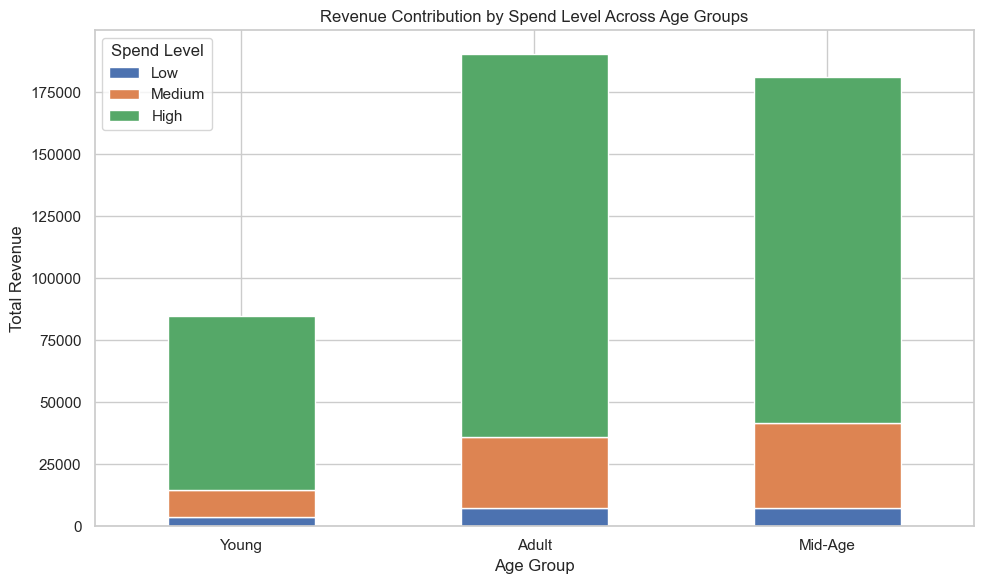

In [39]:
seg_table.plot(kind='bar', stacked=True, figsize=(10,6))

plt.title('Revenue Contribution by Spend Level Across Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.legend(title='Spend Level')
plt.tight_layout()
plt.show()

- High spenders dominate revenue across all age groups
- Adult (High) generates the highest revenue 
- Young (High) contributes less ( ≈ 70K) but still leads within its group
- Low and Medium spenders contribute minimally across all segments

Insight:Revenue is heavily driven by high-spending customers, especially in Adult and Mid-Age groups. The low contribution from mid and low spenders highlights an opportunity to increase revenue by converting these segments, reducing reliance on a single high-value group.

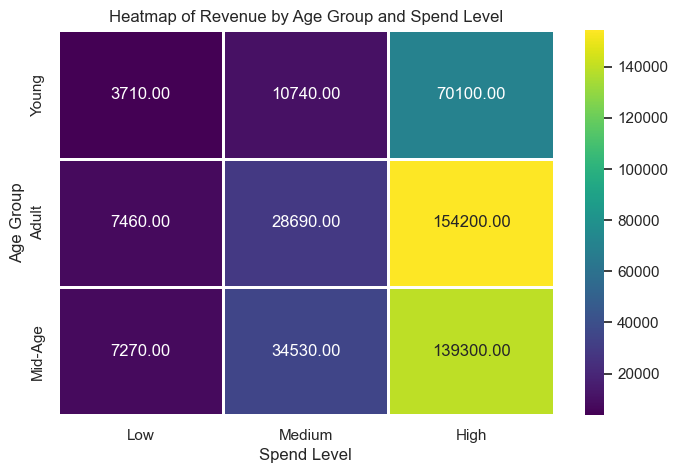

In [40]:
plt.figure(figsize=(8,5))
sns.heatmap(seg_table,annot = True,fmt=".2f",cmap="viridis",linewidth=2)
plt.title('Heatmap of Revenue by Age Group and Spend Level')
plt.xlabel('Spend Level')
plt.ylabel('Age Group')

plt.show()

- High spenders dominate revenue across all age groups, shown by the brightest cells
- Adult (High) records the highest revenue ( ≈ 154K) followed by Mid-Age (High) ( ≈ 139K)
- Young (High) contributes significantly less ( ≈ 70K) compared to other high-spend segments
- Low spenders show consistently minimal contribution across all age groups
- The contrast between High vs Low/Medium spend levels is clearly visible across the heatmap

Insight: The heatmap highlights a strong concentration of revenue among high-spending customers, particularly within Adult and Mid-Age groups. The sharp disparity between spend levels indicates an over-reliance on high-value customers, creating an opportunity to drive growth by converting Low and Medium spenders—especially in the Young segment—into higher spending tiers for more balanced revenue distribution.

## Phase 8: RFM Analysis

In [41]:
### create rfm table
import datetime as dt
snapshot_date = df['Date'].max() + pd.Timedelta(days=1)
rfm = df.groupby('Customer ID').agg({
     'Date': lambda x: (snapshot_date - x.max()).days,    # Recency
    'Transaction ID': 'count',                            # Frequency
    'Revenue': 'sum'                                      # Monetary
})
rfm.columns = ['Recency','Frequency','Monetary']
rfm.head(10)

,Recency,Frequency,Monetary
Customer ID,,,
CUST001,39,1,150
CUST002,309,1,1000
CUST003,354,1,30
CUST004,226,1,500
CUST005,241,1,100
CUST006,252,1,30
CUST007,295,1,50
CUST008,314,1,100
CUST009,20,1,600


In [42]:
## RFM scoring
rfm['R_score'] = pd.qcut(rfm['Recency'],5,labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'),5,labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['Monetary'],5,labels=[1,2,3,4,5])
rfm

,Recency,Frequency,Monetary,R_score,F_score,M_score
Customer ID,,,,,,
CUST001,39,1,150,5,1,3
CUST002,309,1,1000,1,1,4
CUST003,354,1,30,1,1,1
CUST004,226,1,500,2,1,4
CUST005,241,1,100,2,1,2
...,...,...,...,...,...,...
CUST995,247,1,30,2,5,1
CUST996,231,1,50,2,5,1
CUST997,46,1,90,5,5,2


In [43]:
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

In [44]:
rfm[['R_score','F_score','M_score']] = rfm[['R_score','F_score','M_score']].astype(int)
def segment(row):
    if row['R_score'] == 5 and row['F_score'] >=4 and row['M_score']>=4:
        return 'High-Value Customers'
    elif row['F_score'] >= 4 and row['M_score']>=3:
        return 'High Spenders'
    elif row['R_score'] >=4 and row['F_score'] >=3:
        return 'Growth Customers'
    elif row['R_score'] <= 2 and row['F_score'] >=3:
        return 'Declining Customers'
    else:
        return 'Inactive Customers'
rfm['Segment'] = rfm.apply(segment,axis=1)
rfm

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
Customer ID,,,,,,,,
CUST001,39,1,150,5,1,3,513,Inactive Customers
CUST002,309,1,1000,1,1,4,114,Inactive Customers
CUST003,354,1,30,1,1,1,111,Inactive Customers
CUST004,226,1,500,2,1,4,214,Inactive Customers
CUST005,241,1,100,2,1,2,212,Inactive Customers
...,...,...,...,...,...,...,...,...
CUST995,247,1,30,2,5,1,251,Declining Customers
CUST996,231,1,50,2,5,1,251,Declining Customers
CUST997,46,1,90,5,5,2,552,Growth Customers


In [45]:
rfm['Segment'].value_counts()

Segment
Inactive Customers      481
High Spenders           171
Growth Customers        162
Declining Customers     152
High-Value Customers     34
Name: count, dtype: int64

In [46]:
## Segment analysis
segment_analysis = rfm.groupby('Segment').agg(
    Avg_Recency = ('Recency', 'mean'),
    Avg_Frequency = ('Frequency', 'mean'),
    Avg_Monetary = ('Monetary', 'mean'),
    Total_Revenue = ('Monetary', 'sum'),
    Customer_Count = ('RFM_Score', 'count')
)

segment_analysis.sort_values(by='Total_Revenue',ascending=False)

,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Customer_Count
Segment,,,,,
Inactive Customers,188.444906,1.0,454.074844,218410,481
High Spenders,204.081871,1.0,713.040936,121930,171
Growth Customers,73.716049,1.0,272.839506,44200,162
Declining Customers,291.638158,1.0,278.684211,42360,152
High-Value Customers,34.441176,1.0,855.882353,29100,34


### Segment Insights:
#### High-Value Customers
- Lowest recency and highest spending customers
- Contribute significantly to total revenue despite small size
- Should be prioritized for retention strategies
#### High Spenders 
- Customers with high average spending but not recent purchases
- Represent strong revenue contributors but show declining engagement
- Suitable for targeted re-engagement and promotional campaigns
#### Growth Customers
- Relatively recent customers with lower average spending
- Indicate potential for future high-value conversion
- Can be nurtured through personalized offers and upselling strategies
#### Declining Customers
- Customers with high inactivity and low recent engagement
- Previously active but now showing reduced interaction
- Require selective re-engagement efforts or low-cost marketing strategies
#### Inactive Customers
- Largest customer group with high recency (inactive)
- Moderate spending but low engagement
- Indicates a need for re-engagement campaigns
  
Note: Frequency was not a strong differentiator in this dataset, as most customers had only a single transaction. Therefore, segmentation is primarily driven by Recency and Monetary values.

**INSIGHT:** 
The analysis shows that a large portion of customers are inactive, indicating a retention gap. High-value customers contribute significantly but are limited in number. Growth customers present an opportunity for revenue expansion, while declining customers require selective re-engagement strategies.

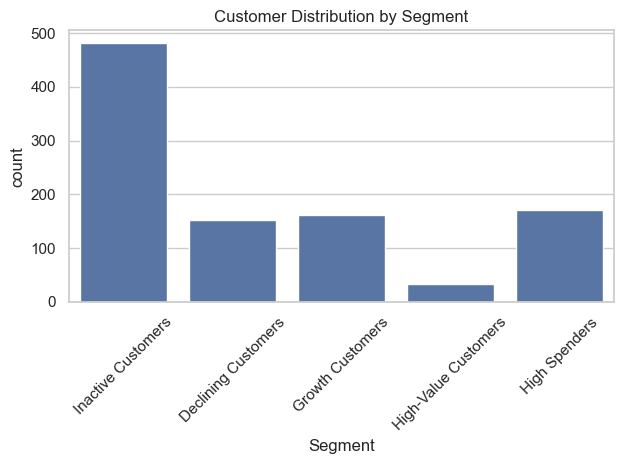

In [47]:
# Segment Distribution
sns.countplot(x='Segment',data=rfm)
plt.title("Customer Distribution by Segment")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:**
- Inactive Customers form the largest segment at  ≈ 480, nearly 3x the size of any other segment, revealing a critical retention problem that demands immediate re-engagement campaigns.
- High-Value Customers are the smallest segment ( ≈ 30), indicating that only a tiny fraction of the customer base reaches premium status — highlighting a significant gap in customer development and upselling efforts.

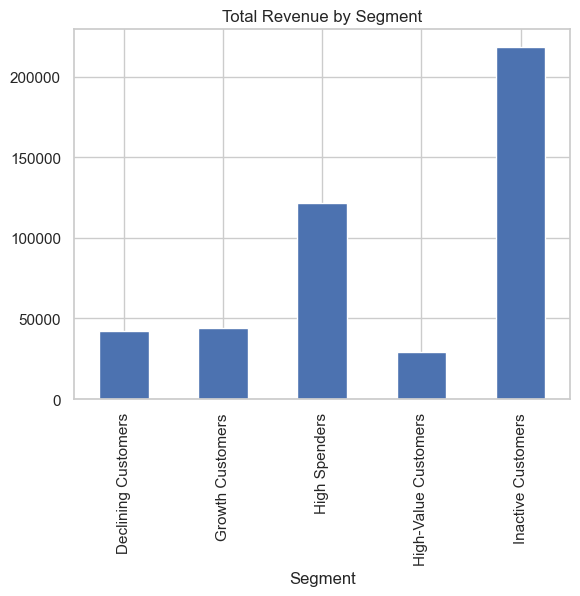

In [51]:
## Revenue vs segment
rfm.groupby('Segment')['Monetary'].sum().plot(kind='bar')
plt.title("Total Revenue by Segment")
plt.show()

**Insight:**
- Inactive Customers generate the highest total revenue ( ≈ 220,000) despite being disengaged, suggesting they were once high-value buyers — making them a top priority for re-engagement campaigns.
- High Spenders contribute ( ≈ 120,000) in revenue from a relatively small count, confirming their high per-customer value, while High-Value Customers paradoxically generate the least ( ≈ 25,000) — indicating a possible mislabeling or scoring inconsistency worth investigating.

Text(0.5, 1.0, 'Segment Distribution by Age Group')

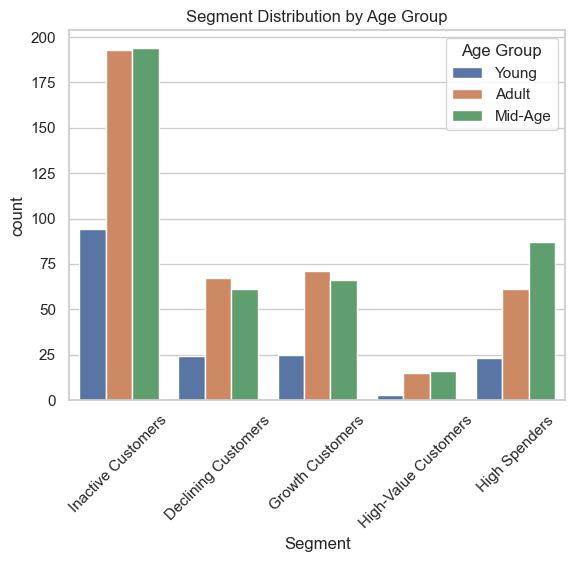

In [49]:
# Segment vs Age Group
merged = df.merge(rfm, on='Customer ID')

sns.countplot(x='Segment', hue='Age Group', data=merged)
plt.xticks(rotation=45)
plt.title("Segment Distribution by Age Group")

**Insight:**
- Inactive Customers dominate all age groups, with Adult and Mid-Age having the highest counts ( ≈ 190 each), signaling a major churn problem across the customer base.
- High Spenders are notably concentrated in the Mid-Age group ( ≈ 85), while Young customers are nearly absent in the High-Value and High Spenders segments — suggesting younger customers are significantly under-monetized.

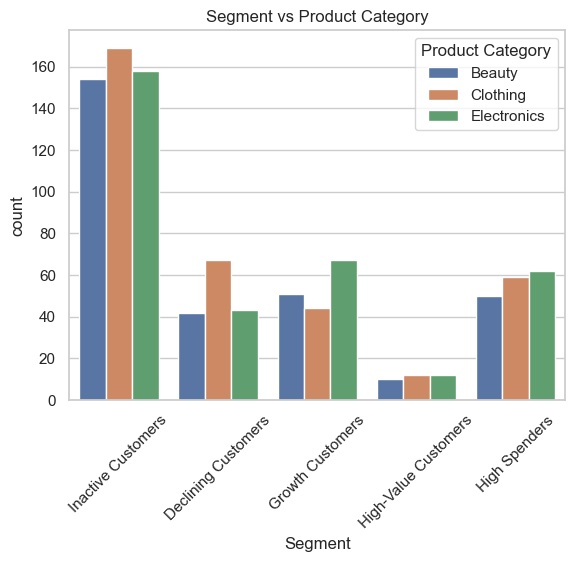

In [52]:
# Segment vs Product Category
sns.countplot(x='Segment', hue='Product Category', data=merged)
plt.xticks(rotation=45)
plt.title("Segment vs Product Category")
plt.show()

**Insight:**
- Clothing dominates the Inactive Customers segment ( ≈ 165) compared to Beauty and Electronics ( ≈ 155 each), suggesting Clothing has the highest churn volume and needs stronger retention or re-engagement strategies.
- Electronics leads in both Growth Customers ( ≈ 66) and High Spenders ( ≈ 61), indicating it is the most commercially promising category — making it a prime target for upselling and loyalty investment to accelerate revenue growth.

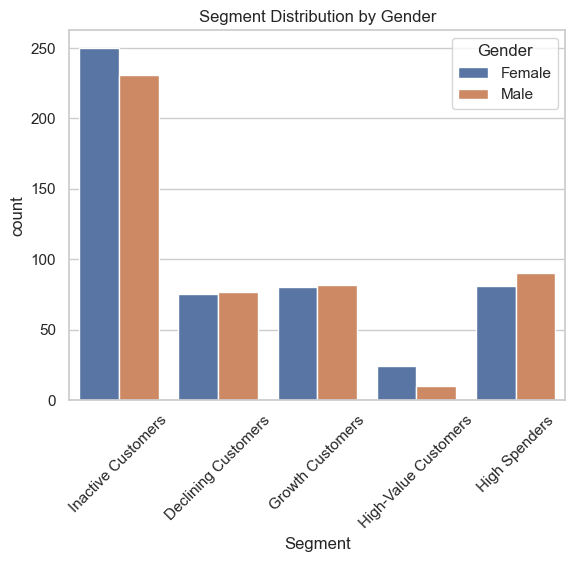

In [53]:
# Segment vs Gender
sns.countplot(x='Segment', hue='Gender', data=merged)
plt.xticks(rotation=45)
plt.title("Segment Distribution by Gender")
plt.show()

**Insight:**
- Inactive Customers dominate both genders ( ≈ 250 Female,  ≈ 230 Male), confirming churn is a gender-neutral problem requiring broad re-engagement strategies rather than gender-specific targeting.
- Females significantly outnumber Males in High-Value Customers ( ≈ 25 vs  ≈ 10), yet Males slightly lead in High Spenders ( ≈ 88 vs  ≈ 80) — suggesting females transact at higher value while males spend more per transaction, pointing to distinct monetization strategies needed for each gender.